# Cosine Similarity and GEH Tests — THS Survey vs Cellular vs Hybrid

Two complementary similarity tests on the three AM-peak (6:00–9:00) demand matrices of the study area, at every zone resolution the pipeline uses:

| Matrix | Source | Scale |
|---|---|---|
| **THS survey** | `Input/trips_ths_2017.xlsx` — the **trips file**, survey days **1 and 2** (day 1, day 2, and their cell-wise average), rebuilt here with the exact extraction and allocation chain of `THS_2017_trips_matrices.ipynb`. The older activities file (`ACTIVITIES_DEC18_corrected.csv`, days 10 / 20) is **not** read anywhere in this notebook — asserted below. | expanded trips (`new_wf`) |
| **Cellular** | `Input/Matrices/AvgDayHourlyTrips201819_1270_weekday_v1.csv`, `h6`–`h8`, study-area zones, allocated to study TAZs **total-preservingly** (each cellular trip counted once — the pipeline's replicated variant is kept as a sensitivity) | cellular product's own AM volumes |
| **Hybrid** | `Output/ths2017/study_taz/hybrid_taz_trips.csv` — the primary SZ-calibrated fusion product of `THS_2017_hybrid_pipeline.ipynb` (GS-calibrated variant as a sensitivity) | survey origin totals |

**Cosine similarity** answers *"is the pattern of demand across OD pairs the same?"* — it is scale-free and dominated by large cells. **GEH** answers *"cell by cell, are the volumes within the tolerance transport guidance uses for counts?"* — it needs a common scale, so it is run both on raw volumes (a scale audit) and after matching the cellular matrix to the survey scale.

| # | Test | Statistic | Reference level |
|---|---|---|---|
| C1 | Whole-matrix cosine | cos(A, B) on flattened matrices; raw, off-diagonal, log-transformed, row-normalized | survey day 1 vs day 2 (internal-consistency ceiling); permuted-geography null (chance) |
| C2 | Per-origin cosine | cos of destination profiles, row by row (SZ table; TAZ distribution, volume-weighted) | day 1 vs day 2 |
| C3 | Chance level | permuted-geography null for C1 | — |
| G1 | Scale audit | totals, origin / destination totals per superzone and per cellular zone, diagonal share — GEH on absolute volumes | — |
| G2 | Cell-level GEH, scale-matched | cellular × (survey total / cellular total) or row-matched (cellular P × survey origin totals); pass rates at GEH < 5 / < 10, by flow band | day 1 vs day 2 |
| G3 | Corridor GEH | corridor-class flows (both ends / one end / neither in the 119 corridor TAZs) and the 28 aggregated sub-areas | day 1 vs day 2 |

GEH is defined for **hourly** flows: every 3-hour AM matrix is divided by 3 before GEH is computed (a 3-hour GEH would be √3 ≈ 1.73 × larger).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

rng = np.random.default_rng(42)

# palette (repo convention: blue = survey day 1, orange = survey day 2; aqua = cellular; purple = hybrid)
BLUE, ORANGE, AQUA, PURPLE = '#2a78d6', '#eb6834', '#1baf7a', '#7b5bd6'
INK, INK2, MUTED, GRID, AXIS = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'
CMAP_SEQ = LinearSegmentedColormap.from_list(
    'seq_blue', ['#fcfcfb', '#cde2fb', '#9ec5f4', '#6da7ec', '#3987e5', '#256abf', '#184f95', '#0d366b'])

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    ax.grid(True, color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)
    for s in ax.spines.values():
        s.set_color(AXIS)
    ax.tick_params(colors=INK2, labelsize=9)
    if title: ax.set_title(title, color=INK, fontsize=12)
    if xlabel: ax.set_xlabel(xlabel, color=INK2, fontsize=10)
    if ylabel: ax.set_ylabel(ylabel, color=INK2, fontsize=10)

OUT = 'Output/ths2017/tests'
os.makedirs(OUT, exist_ok=True)
os.makedirs('Output/figures', exist_ok=True)
def save_show(fig, name):
    fig.savefig(f'Output/figures/{name}', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

## 1. Data

### 1a. Survey matrices from the trips file (days 1 and 2)

Exact replica of `THS_2017_trips_matrices.ipynb`: trips from `placeno` order per `PerID3` × `SurveyDay`, departure hour = the origin row's `Dep_h` ∈ {6, 7, 8}, weight `new_wf`; `actTaz` (2636 system) → `TAZ_1250` → study TAZ, the one-to-many last link allocated by cellular outflow / inflow shares (`M_taz = Sₒᵀ · M₁₂₅₀ · S_d`); both trip ends inside the study area. Validated against the saved `matrix_avg_ALL_taz.csv`.

In [2]:
# ---- provenance guard: the survey source is the trips file, survey days 1 and 2 ----
TRIPS_FILE = 'Input/trips_ths_2017.xlsx'
df = pd.read_excel(TRIPS_FILE)
assert set(df['SurveyDay'].unique()) == {1, 2}, "the trips file must carry survey days 1 and 2 only"
print(f"{TRIPS_FILE}: {len(df):,} activity rows, {df['PerID3'].nunique():,} persons, survey days {sorted(df['SurveyDay'].unique())}")

d = df.sort_values(['PerID3', 'SurveyDay', 'placeno']).copy()
g = d.groupby(['PerID3', 'SurveyDay'])
d['origin'] = g['actTaz'].shift(1)
d['trip_dep_h'] = g['Dep_h'].shift(1)
trips = d.dropna(subset=['origin', 'actTaz', 'trip_dep_h'])
trips = trips[trips['trip_dep_h'].isin([6, 7, 8])]
assert (trips['mode'] != 'IRR').all()

k26 = pd.read_excel('Input/TAZ_2636_Keys.xlsx').drop_duplicates('TAZ_2636')
map_2636_1250 = k26.set_index('TAZ_2636')['TAZ_1250']
trips = trips.assign(o1250=trips['origin'].map(map_2636_1250), d1250=trips['actTaz'].map(map_2636_1250))
assert trips[['o1250', 'd1250']].notna().all().all(), "every actTaz must map to a 1250-zone"

# ---- cellular at study TAZ + allocation matrices (replica of the pipeline) ----
keys_raw = pd.read_csv('Input/Matrices/1270_02_09_2021_TAZ_North_keys.csv', encoding='windows-1255')
kn = keys_raw[['TAZ_1270', 'TAZ_NUMBER']].dropna(subset=['TAZ_NUMBER'])
kn['TAZ_NUMBER'] = kn['TAZ_NUMBER'].astype(int)
kd = kn.drop_duplicates('TAZ_NUMBER')

cellular = pd.read_csv('Input/Matrices/AvgDayHourlyTrips201819_1270_weekday_v1.csv')[['fromZone', 'ToZone', 'h6', 'h7', 'h8']]
c = cellular.merge(kd.rename(columns={'TAZ_1270': 'fromZone', 'TAZ_NUMBER': 'fromTaz'}), on='fromZone')
c = c.merge(kd.rename(columns={'TAZ_1270': 'ToZone', 'TAZ_NUMBER': 'ToTaz'}), on='ToZone')
cell_taz_repl = c.groupby(['fromTaz', 'ToTaz'])[['h6', 'h7', 'h8']].sum().sum(axis=1).unstack().fillna(0)   # pipeline's replicated variant
TAZ = cell_taz_repl.index
N = len(TAZ)
out_vol, in_vol = cell_taz_repl.sum(axis=1), cell_taz_repl.sum(axis=0)

saved_cell_prob = pd.read_csv('Output/prob_matrix_cellular.csv', index_col=0)
saved_cell_prob.columns = saved_cell_prob.columns.astype(int)
cell_prob_repl = cell_taz_repl.div(cell_taz_repl.sum(axis=1), axis=0).fillna(0)
assert np.abs(cell_prob_repl.values - saved_cell_prob.reindex(index=TAZ, columns=TAZ).values).max() < 1e-6
print("validation 1: rebuilt cellular (replicated) probabilities match Output/prob_matrix_cellular.csv")

north_1250 = sorted(kd[kd['TAZ_NUMBER'].isin(TAZ)]['TAZ_1270'].unique())
z_idx = {z: i for i, z in enumerate(north_1250)}
children = kd[kd['TAZ_NUMBER'].isin(TAZ)].groupby('TAZ_1270')['TAZ_NUMBER'].apply(list)
taz_pos = {t: j for j, t in enumerate(TAZ)}

def alloc_matrix(vol):
    S = np.zeros((len(north_1250), N))
    for z, kids in children.items():
        v = np.array([vol[t] for t in kids], float)
        s = v / v.sum() if v.sum() > 0 else np.full(len(kids), 1 / len(kids))
        for t, sh in zip(kids, s):
            S[z_idx[z], taz_pos[t]] = sh
    return S

S_o, S_d = alloc_matrix(out_vol), alloc_matrix(in_vol)
assert np.allclose(S_o.sum(axis=1), 1) and np.allclose(S_d.sum(axis=1), 1)

in_study = trips['o1250'].isin(z_idx) & trips['d1250'].isin(z_idx)
tm = trips[in_study]

def survey_1250(day):
    td = tm[tm['SurveyDay'] == day]
    m = td.groupby(['o1250', 'd1250'])['new_wf'].sum().unstack().fillna(0)
    return m.reindex(index=north_1250, columns=north_1250, fill_value=0).values

S1_1250, S2_1250 = survey_1250(1), survey_1250(2)
S1, S2 = S_o.T @ S1_1250 @ S_d, S_o.T @ S2_1250 @ S_d
SAVG = (S1 + S2) / 2
saved_avg = pd.read_csv('Output/ths2017/study_taz/matrix_avg_ALL_taz.csv', index_col=0)
saved_avg.columns = saved_avg.columns.astype(int)
rel = np.abs(SAVG - saved_avg.reindex(index=TAZ, columns=TAZ).values).max() / saved_avg.values.max()
assert rel < 1e-4
print(f"validation 2: day-averaged trips-file matrix matches saved matrix_avg_ALL_taz.csv (max rel diff {rel:.1e})")
print(f"survey AM trips in the study area: day 1 {S1.sum():,.0f} ({(tm['SurveyDay']==1).sum():,} sampled), "
      f"day 2 {S2.sum():,.0f} ({(tm['SurveyDay']==2).sum():,} sampled), average {SAVG.sum():,.0f}")

Input/trips_ths_2017.xlsx: 146,394 activity rows, 16,401 persons, survey days [np.int64(1), np.int64(2)]


validation 1: rebuilt cellular (replicated) probabilities match Output/prob_matrix_cellular.csv
validation 2: day-averaged trips-file matrix matches saved matrix_avg_ALL_taz.csv (max rel diff 2.4e-06)
survey AM trips in the study area: day 1 2,077,302 (13,476 sampled), day 2 2,059,015 (13,387 sampled), average 2,068,158


### 1b. Cellular volumes, hybrid matrix, zone systems

The cellular matrix enters the pipeline as **replicated** TAZ cells (every child-TAZ pair of a 1250-zone pair carries the full zone-pair value — METHODOLOGY §8 caveat 2), which is fine for probabilities but inflates volumes (the study-area replicated total is 6.4 × the native one). For volume tests the cellular matrix is therefore **allocated** with the same `Sₒᵀ · C₁₂₅₀ · S_d` chain as the survey, so each cellular trip is counted once and the study-area total is preserved. The replicated probabilities (`prob_matrix_cellular.csv`) are kept as the "pipeline variant" sensitivity in C1.

In [3]:
# native cellular inside the study area (1250-zone level), then allocated to TAZs
cn = cellular[cellular['fromZone'].isin(z_idx) & cellular['ToZone'].isin(z_idx)]
C_1250 = (cn.assign(v=cn[['h6', 'h7', 'h8']].sum(axis=1)).groupby(['fromZone', 'ToZone'])['v'].sum()
          .unstack().reindex(index=north_1250, columns=north_1250, fill_value=0).fillna(0).values)
C = S_o.T @ C_1250 @ S_d                      # allocated, total-preserving
assert abs(C.sum() - C_1250.sum()) < 1e-6
C_repl = cell_taz_repl.values                  # pipeline's replicated variant (probabilities only)
print(f"cellular AM trips in the study area: native {C_1250.sum():,.0f} over {len(north_1250)} zones; "
      f"replicated TAZ total {C_repl.sum():,.0f} (× {C_repl.sum()/C_1250.sum():.1f})")

# hybrid (primary: SZ-calibrated; sensitivity: GS-calibrated)
def load_sq(path):
    m = pd.read_csv(path, index_col=0)
    m.index = m.index.astype(float).astype(int); m.columns = m.columns.astype(float).astype(int)
    return m.reindex(index=TAZ, columns=TAZ).fillna(0).values
H = load_sq('Output/ths2017/study_taz/hybrid_taz_trips.csv')
H_gs = load_sq('Output/ths2017/study_taz/hybrid_taz_trips_gs.csv')
assert abs(H.sum() - SAVG.sum()) < 1, "hybrid carries the survey scale"
print(f"hybrid trips: SZ-calibrated {H.sum():,.0f}, GS-calibrated {H_gs.sum():,.0f}")

# zone systems: superzone (36), GS (25), 28 aggregated sub-areas (205 TAZs), corridor flag (119 TAZs)
taz_to_sz = keys_raw[['TAZ_NUMBER', 'SZ_NEW']].dropna().astype(int).drop_duplicates('TAZ_NUMBER').set_index('TAZ_NUMBER')['SZ_NEW']
taz_to_gs = pd.read_csv('Input/TAZ_GSnew.csv').set_index('TAZ')['GS']
sub_key = pd.read_excel('Input/Submatrix_tazs.xlsx')
taz_to_area = sub_key.set_index('TAZ')['AggAreaCode']
area_names = sub_key.drop_duplicates('AggAreaCode').set_index('AggAreaCode')['AggAreaName']
corridor = np.array([t in set(sub_key.loc[sub_key['IsLRT_Corridor'] == 1, 'TAZ']) for t in TAZ])

def indicator(mapping):
    zones = sorted({mapping[t] for t in TAZ if t in mapping.index})
    pos = {z: i for i, z in enumerate(zones)}
    M = np.zeros((N, len(zones)))
    for j, t in enumerate(TAZ):
        if t in mapping.index:
            M[j, pos[mapping[t]]] = 1
    return zones, M

SZ, M_sz = indicator(taz_to_sz)
GS, M_gs = indicator(taz_to_gs)
AREA, M_area = indicator(taz_to_area)
assert M_sz.sum() == N and M_gs.sum() == N and M_area.sum() == 205
hyb_sz_saved = pd.read_csv('Output/ths2017/study_taz/hybrid_sz_trips.csv', index_col=0).values
agg_h = M_sz.T @ H @ M_sz
assert np.abs(agg_h.sum(axis=1) - hyb_sz_saved.sum(axis=1)).max() < 1, "SZ origin totals of the TAZ hybrid must match hybrid_sz_trips.csv"
print(f"validation 3: TAZ hybrid aggregated to superzones reproduces hybrid_sz_trips.csv origin totals exactly; cells differ by "
      f"{np.abs(agg_h - hyb_sz_saved).sum() / hyb_sz_saved.sum():.1%} of trips (the TAZ row re-normalization after the R_AB scaling) — "
      f"the superzone tests below use the aggregated TAZ hybrid, i.e. the delivered matrix")
print(f"zone systems: {len(SZ)} superzones, {len(GS)} GS zones, {len(AREA)} aggregated sub-areas ({int(M_area.sum())} TAZs), {corridor.sum()} corridor TAZs")

LEVELS = {'TAZ': np.eye(N), 'SZ': M_sz, 'GS': M_gs, 'AREA': M_area}
LABELS = {'TAZ': list(TAZ), 'SZ': SZ, 'GS': GS, 'AREA': AREA}
def at(level, X):
    M = LEVELS[level]
    return M.T @ X @ M

# sources at each level (AREA = trips with both ends inside the 205-TAZ sub-area)
SRC = {'survey d1': S1, 'survey d2': S2, 'survey avg': SAVG, 'cellular': C, 'hybrid': H, 'hybrid (GS-cal.)': H_gs}
MAT = {lvl: {k: at(lvl, v) for k, v in SRC.items()} for lvl in LEVELS}
MAT['SZ']['cellular (replicated)'] = at('SZ', C_repl)
MAT['GS']['cellular (replicated)'] = at('GS', C_repl)
pd.DataFrame({lvl: {k: v.sum() for k, v in MAT[lvl].items()} for lvl in LEVELS}).round(0)

cellular AM trips in the study area: native 580,506 over 396 zones; replicated TAZ total 3,736,545 (× 6.4)


hybrid trips: SZ-calibrated 2,068,158, GS-calibrated 2,068,159


validation 3: TAZ hybrid aggregated to superzones reproduces hybrid_sz_trips.csv origin totals exactly; cells differ by 2.0% of trips (the TAZ row re-normalization after the R_AB scaling) — the superzone tests below use the aggregated TAZ hybrid, i.e. the delivered matrix
zone systems: 36 superzones, 25 GS zones, 28 aggregated sub-areas (205 TAZs), 119 corridor TAZs


,TAZ,SZ,GS,AREA
survey d1,2077302.0,2077302.0,2077302.0,276774.0
survey d2,2059015.0,2059015.0,2059015.0,277180.0
survey avg,2068158.0,2068158.0,2068158.0,276977.0
cellular,580506.0,580506.0,580506.0,76343.0
hybrid,2068158.0,2068158.0,2068158.0,273320.0
hybrid (GS-cal.),2068159.0,2068159.0,2068159.0,243771.0
cellular (replicated),NaN,3736545.0,3736545.0,NaN


## 2. Metrics

- **Cosine similarity**: `cos(A, B) = ⟨a, b⟩ / (‖a‖ ‖b‖)` on the flattened matrices. Variants: *raw* (dominated by the largest cells), *off-diagonal* (intra-zonal cells removed — the known survey / cellular divergence), *log1p* (compresses the big cells; computed after matching the cellular scale to the survey total), *row-normalized* (each origin's destination shares, so scale per origin drops out).
- **Per-origin cosine**: the same statistic row by row — 1.0 means the origin sends its trips to destinations in the same proportions in both matrices.
- **GEH** per cell: `√(2 (m − c)² / (m + c))` on hourly flows (3-hour matrix / 3). Convention from link-count validation: GEH < 5 is a good match, < 10 acceptable. Reported as the share of cells passing (unweighted and weighted by the cell's mean flow) on cells with a non-zero mean flow, and by flow band because GEH is unstable on very small flows.

In [4]:
def cosine(a, b, mask=None):
    a, b = np.asarray(a, float).ravel(), np.asarray(b, float).ravel()
    if mask is not None:
        m = np.asarray(mask, bool).ravel(); a, b = a[m], b[m]
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    return float(a @ b / (na * nb)) if na > 0 and nb > 0 else np.nan

def rownorm(X):
    rs = X.sum(axis=1, keepdims=True)
    return np.where(rs > 0, X / np.where(rs == 0, 1, rs), 0)

def row_cosine(A, B):
    num = (A * B).sum(axis=1)
    den = np.linalg.norm(A, axis=1) * np.linalg.norm(B, axis=1)
    return np.where(den > 0, num / np.where(den == 0, 1, den), np.nan)

def geh(m, c):
    m, c = np.asarray(m, float) / 3.0, np.asarray(c, float) / 3.0     # hourly flows
    s = m + c
    with np.errstate(divide='ignore', invalid='ignore'):
        return np.where(s > 0, np.sqrt(2 * (m - c) ** 2 / np.where(s == 0, 1, s)), np.nan)

def geh_summary(m, c):
    """pass rates on cells with non-zero mean flow; weights = mean hourly flow"""
    G = geh(m, c)
    w = (np.asarray(m, float) + np.asarray(c, float)) / 6.0
    ok = ~np.isnan(G)
    G, w = G[ok], w[ok]
    return {'cells': int(ok.sum()), 'GEH<5': float((G < 5).mean()), 'GEH<10': float((G < 10).mean()),
            'GEH<5 (flow-wtd)': float(w[G < 5].sum() / w.sum()), 'GEH<10 (flow-wtd)': float(w[G < 10].sum() / w.sum()),
            'median GEH': float(np.median(G)), 'mean GEH (flow-wtd)': float((G * w).sum() / w.sum())}

def scale_global(X, target):
    return X * (target.sum() / X.sum())

def scale_rows(X, target):
    """row-matched: X's destination pattern × target's origin totals"""
    return rownorm(X) * target.sum(axis=1, keepdims=True)

## C1. Whole-matrix cosine similarity

All pairs, at every level, four variants. The reference is **survey day 1 vs day 2**: the same households on two different days, so this is the ceiling any source can reach against the survey given its sampling noise. `cellular (replicated)` is the pipeline's own cellular variant, shown only at SZ / GS where the replication caveat bites.

In [5]:
PAIRS = [('survey d1', 'survey d2'), ('survey d1', 'cellular'), ('survey d2', 'cellular'), ('survey avg', 'cellular'),
         ('hybrid', 'cellular'), ('hybrid', 'survey avg'), ('hybrid', 'survey d1'), ('hybrid', 'survey d2'),
         ('hybrid (GS-cal.)', 'cellular'), ('hybrid (GS-cal.)', 'survey avg'),
         ('cellular (replicated)', 'cellular'), ('survey avg', 'cellular (replicated)'), ('hybrid', 'cellular (replicated)')]

rows = []
for lvl in ['SZ', 'GS', 'AREA', 'TAZ']:
    n = len(LABELS[lvl]); offdiag = ~np.eye(n, dtype=bool)
    for a, b in PAIRS:
        if a not in MAT[lvl] or b not in MAT[lvl]:
            continue
        A, B = MAT[lvl][a], MAT[lvl][b]
        Bs = scale_global(B, A)
        rows.append({'level': lvl, 'A': a, 'B': b, 'pair': f'{a} vs {b}',
                     'raw': cosine(A, B), 'off-diagonal': cosine(A, B, offdiag),
                     'log1p (scale-matched)': cosine(np.log1p(A), np.log1p(Bs)),
                     'row-normalized': cosine(rownorm(A), rownorm(B))})
cos_tbl = pd.DataFrame(rows)
cos_tbl.to_csv(f'{OUT}/cosine_whole_matrix.csv', index=False, float_format='%.4f')

show = cos_tbl[~cos_tbl['pair'].str.contains('replicated') & ~cos_tbl['pair'].str.contains('GS-cal')]
pv = show.pivot(index='pair', columns='level', values=['raw', 'off-diagonal', 'log1p (scale-matched)', 'row-normalized'])
order = [f'{a} vs {b}' for a, b in PAIRS if f'{a} vs {b}' in pv.index]
pv = pv.loc[order].reindex(columns=['SZ', 'GS', 'AREA', 'TAZ'], level=1)
pv.round(3)

raw                      off-diagonal                \
level                      SZ     GS   AREA    TAZ           SZ     GS   AREA   
pair                                                                            
survey d1 vs survey d2  0.996  0.999  0.997  0.972        0.974  0.983  0.978   
survey d1 vs cellular   0.916  0.953  0.893  0.437        0.850  0.912  0.676   
survey d2 vs cellular   0.913  0.952  0.899  0.440        0.840  0.909  0.683   
survey avg vs cellular  0.915  0.953  0.897  0.442        0.851  0.914  0.683   
hybrid vs cellular      0.917  0.963  0.902  0.734        0.859  0.866  0.804   
hybrid vs survey avg    1.000  0.994  0.960  0.432        0.999  0.903  0.855   
hybrid vs survey d1     0.999  0.994  0.963  0.429        0.993  0.892  0.841   
hybrid vs survey d2     0.999  0.994  0.956  0.430        0.993  0.906  0.859   

                              log1p (scale-matched)                       \
level                     TAZ                    SZ     GS   AREA    TAZ   
pair                                                                       
survey d1 vs survey d2  0.940                 0.926  0.941  0.867  0.787   
survey d1 vs cellular   0.407                 0.833  0.839  0.748  0.396   
survey d2 vs cellular   0.413                 0.831  0.832  0.735  0.398   
survey avg vs cellular  0.417                 0.861  0.859  0.787  0.431   
hybrid vs cellular      0.737                 0.913  0.943  0.961  0.860   
hybrid vs survey avg    0.538                 0.991  0.948  0.836  0.534   
hybrid vs survey d1     0.526                 0.965  0.930  0.802  0.496   
hybrid vs survey d2     0.533                 0.963  0.925  0.792  0.505   

                       row-normalized                       
level                              SZ     GS   AREA    TAZ  
pair                                                        
survey d1 vs survey d2          0.998  0.986  0.885  0.675  
survey d1 vs cellular           0.870  0.852  0.664  0.411  
survey d2 vs cellular           0.869  0.846  0.659  0.413  
survey avg vs cellular          0.870  0.852  0.681  0.437  
hybrid vs cellular              0.874  0.891  0.805  0.825  
hybrid vs survey avg            1.000  0.968  0.842  0.484  
hybrid vs survey d1             0.999  0.967  0.830  0.458  
hybrid vs survey d2             0.999  0.962  0.804  0.463

In [6]:
print("sensitivities (SZ / GS):")
cos_tbl[cos_tbl['pair'].str.contains('replicated|GS-cal')].set_index(['level', 'pair'])[['raw', 'off-diagonal', 'log1p (scale-matched)', 'row-normalized']].round(3)

sensitivities (SZ / GS):


raw  off-diagonal  \
level pair                                                       
SZ    hybrid (GS-cal.) vs cellular         0.928         0.865   
      hybrid (GS-cal.) vs survey avg       0.967         0.832   
      cellular (replicated) vs cellular    0.843         0.872   
      survey avg vs cellular (replicated)  0.819         0.805   
      hybrid vs cellular (replicated)      0.821         0.809   
GS    hybrid (GS-cal.) vs cellular         0.956         0.919   
      hybrid (GS-cal.) vs survey avg       1.000         0.999   
      cellular (replicated) vs cellular    0.973         0.907   
      survey avg vs cellular (replicated)  0.897         0.819   
      hybrid vs cellular (replicated)      0.914         0.751   
AREA  hybrid (GS-cal.) vs cellular         0.940         0.865   
      hybrid (GS-cal.) vs survey avg       0.873         0.574   
TAZ   hybrid (GS-cal.) vs cellular         0.730         0.739   
      hybrid (GS-cal.) vs survey avg       0.399         0.508   

                                           log1p (scale-matched)  \
level pair                                                         
SZ    hybrid (GS-cal.) vs cellular                         0.967   
      hybrid (GS-cal.) vs survey avg                       0.915   
      cellular (replicated) vs cellular                    0.997   
      survey avg vs cellular (replicated)                  0.864   
      hybrid vs cellular (replicated)                      0.916   
GS    hybrid (GS-cal.) vs cellular                         0.912   
      hybrid (GS-cal.) vs survey avg                       0.990   
      cellular (replicated) vs cellular                    0.997   
      survey avg vs cellular (replicated)                  0.866   
      hybrid vs cellular (replicated)                      0.945   
AREA  hybrid (GS-cal.) vs cellular                         0.981   
      hybrid (GS-cal.) vs survey avg                       0.809   
TAZ   hybrid (GS-cal.) vs cellular                         0.884   
      hybrid (GS-cal.) vs survey avg                       0.511   

                                           row-normalized  
level pair                                                 
SZ    hybrid (GS-cal.) vs cellular                  0.920  
      hybrid (GS-cal.) vs survey avg                0.929  
      cellular (replicated) vs cellular             0.974  
      survey avg vs cellular (replicated)           0.870  
      hybrid vs cellular (replicated)               0.875  
GS    hybrid (GS-cal.) vs cellular                  0.861  
      hybrid (GS-cal.) vs survey avg                0.999  
      cellular (replicated) vs cellular             0.985  
      survey avg vs cellular (replicated)           0.856  
      hybrid vs cellular (replicated)               0.895  
AREA  hybrid (GS-cal.) vs cellular                  0.932  
      hybrid (GS-cal.) vs survey avg                0.683  
TAZ   hybrid (GS-cal.) vs cellular                  0.826  
      hybrid (GS-cal.) vs survey avg                0.476

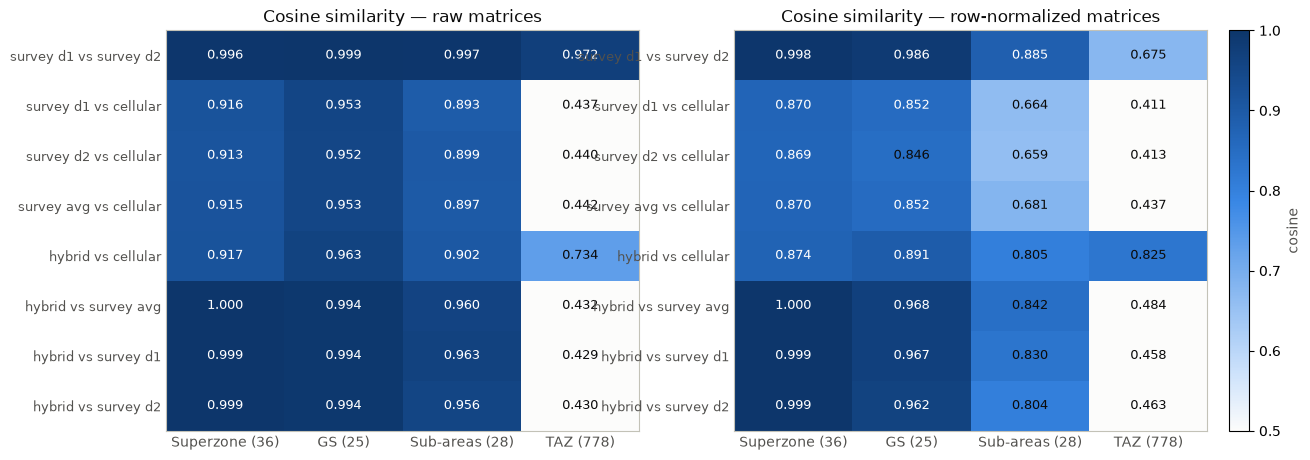

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), facecolor='white')
for ax, variant in zip(axes, ['raw', 'row-normalized']):
    tbl = show.pivot(index='pair', columns='level', values=variant).loc[order, ['SZ', 'GS', 'AREA', 'TAZ']]
    im = ax.imshow(tbl.values, cmap=CMAP_SEQ, vmin=0.5, vmax=1.0, aspect='auto')
    ax.set_xticks(range(4)); ax.set_xticklabels(['Superzone (36)', 'GS (25)', 'Sub-areas (28)', 'TAZ (778)'], color=INK2)
    ax.set_yticks(range(len(tbl))); ax.set_yticklabels(tbl.index, color=INK2, fontsize=9)
    for i in range(tbl.shape[0]):
        for j in range(tbl.shape[1]):
            v = tbl.values[i, j]
            ax.text(j, i, f'{v:.3f}', ha='center', va='center', fontsize=9, color='white' if v > 0.85 else INK)
    ax.set_title(f'Cosine similarity — {variant} matrices', color=INK, fontsize=12)
    for s in ax.spines.values(): s.set_color(AXIS)
    ax.tick_params(length=0)
fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02).set_label('cosine', color=INK2)
save_show(fig, 'cosine_geh_whole_matrix.png')

## C2. Per-origin cosine — destination profiles row by row

Where does the pattern agree and where does it not? The row statistic is computed on destination profiles at superzone level (a table, one row per origin superzone) and at TAZ level (a distribution; volume-weighted mean uses the survey origin total).

In [8]:
def row_table(lvl):
    M = MAT[lvl]
    tbl = pd.DataFrame({
        'origin': LABELS[lvl],
        'survey trips': M['survey avg'].sum(axis=1),
        'd1 vs d2': row_cosine(M['survey d1'], M['survey d2']),
        'survey vs cellular': row_cosine(M['survey avg'], M['cellular']),
        'hybrid vs cellular': row_cosine(M['hybrid'], M['cellular']),
        'hybrid vs survey': row_cosine(M['hybrid'], M['survey avg']),
    })
    offd = ~np.eye(len(LABELS[lvl]), dtype=bool)
    tbl['survey vs cellular (off-diag)'] = row_cosine(M['survey avg'] * offd, M['cellular'] * offd)
    tbl['hybrid vs cellular (off-diag)'] = row_cosine(M['hybrid'] * offd, M['cellular'] * offd)
    return tbl

row_sz = row_table('SZ')
corr_sz = sorted({taz_to_sz[t] for t, f in zip(TAZ, corridor) if f})
row_sz['corridor SZ'] = row_sz['origin'].isin(corr_sz)
row_sz.to_csv(f'{OUT}/cosine_by_origin_sz.csv', index=False, float_format='%.4f')

def wmean(x, w):
    ok = ~np.isnan(x); return float((x[ok] * w[ok]).sum() / w[ok].sum())

summary_rows = []
for lvl in ['SZ', 'GS', 'AREA', 'TAZ']:
    t = row_table(lvl); w = t['survey trips'].values
    for col in ['d1 vs d2', 'survey vs cellular', 'hybrid vs cellular', 'hybrid vs survey', 'survey vs cellular (off-diag)', 'hybrid vs cellular (off-diag)']:
        x = t[col].values
        summary_rows.append({'level': lvl, 'pair': col, 'origins': int((~np.isnan(x)).sum()),
                             'median': float(np.nanmedian(x)), 'p10': float(np.nanpercentile(x, 10)), 'p90': float(np.nanpercentile(x, 90)),
                             'flow-weighted mean': wmean(x, w), 'share < 0.8': float(np.nanmean(x < 0.8))})
row_summary = pd.DataFrame(summary_rows)
row_summary.to_csv(f'{OUT}/cosine_by_origin_summary.csv', index=False, float_format='%.4f')
row_summary.pivot(index='pair', columns='level', values='flow-weighted mean').loc[
    ['d1 vs d2', 'survey vs cellular', 'hybrid vs cellular', 'hybrid vs survey', 'survey vs cellular (off-diag)', 'hybrid vs cellular (off-diag)'],
    ['SZ', 'GS', 'AREA', 'TAZ']].round(3)

level,SZ,GS,AREA,TAZ
pair,,,,
d1 vs d2,0.999,0.999,0.980,0.934
survey vs cellular,0.889,0.894,0.807,0.595
hybrid vs cellular,0.893,0.920,0.857,0.831
hybrid vs survey,1.000,0.980,0.940,0.674
survey vs cellular (off-diag),0.899,0.933,0.684,0.513
hybrid vs cellular (off-diag),0.904,0.934,0.824,0.796


In [9]:
print("per-origin cosine at superzone level (sorted by survey vs cellular):")
print(row_sz.sort_values('survey vs cellular').round(3).to_string(index=False))

per-origin cosine at superzone level (sorted by survey vs cellular):
 origin  survey trips  d1 vs d2  survey vs cellular  hybrid vs cellular  hybrid vs survey  survey vs cellular (off-diag)  hybrid vs cellular (off-diag)  corridor SZ
     10     23433.065     1.000               0.333               0.336             1.000                          0.748                          0.762         True
     11     26725.511     0.999               0.460               0.472             1.000                          0.689                          0.715         True
      6     39569.337     0.997               0.719               0.731             1.000                          0.802                          0.809        False
      5     25796.121     0.996               0.726               0.736             1.000                          0.849                          0.854        False
     30     50689.214     0.999               0.756               0.759             1.000                 

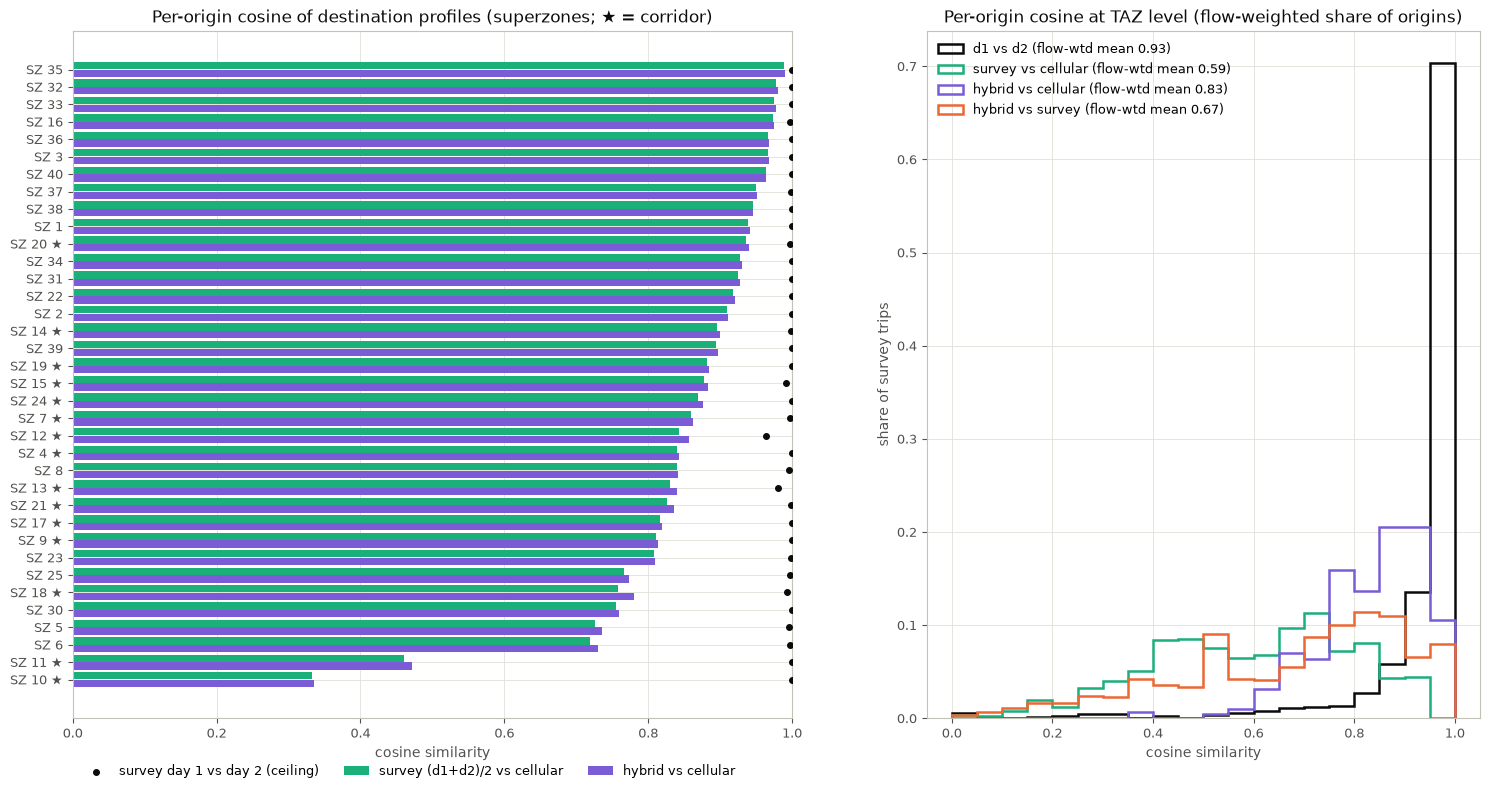

In [10]:
t = row_sz.sort_values('survey vs cellular')
fig, axes = plt.subplots(1, 2, figsize=(15, 8), facecolor='white', gridspec_kw={'width_ratios': [1.3, 1]})
ax = axes[0]
y = np.arange(len(t))
ax.barh(y + 0.22, t['survey vs cellular'], height=0.42, color=AQUA, label='survey (d1+d2)/2 vs cellular')
ax.barh(y - 0.22, t['hybrid vs cellular'], height=0.42, color=PURPLE, label='hybrid vs cellular')
ax.scatter(t['d1 vs d2'], y, color=INK, s=16, zorder=3, label='survey day 1 vs day 2 (ceiling)')
ax.set_yticks(y); ax.set_yticklabels([f"SZ {int(z)}{' ★' if c else ''}" for z, c in zip(t['origin'], t['corridor SZ'])], fontsize=8)
ax.set_xlim(0, 1)
style_ax(ax, 'Per-origin cosine of destination profiles (superzones; ★ = corridor)', 'cosine similarity')
ax.legend(frameon=False, fontsize=9, loc='upper left', bbox_to_anchor=(0, -0.05), ncol=3)

ax = axes[1]
rt = row_table('TAZ'); w = rt['survey trips'].values
bins = np.linspace(0, 1, 21)
for col, color in [('d1 vs d2', INK), ('survey vs cellular', AQUA), ('hybrid vs cellular', PURPLE), ('hybrid vs survey', ORANGE)]:
    x = rt[col].values; ok = ~np.isnan(x)
    ax.hist(x[ok], bins=bins, weights=w[ok] / w[ok].sum(), histtype='step', linewidth=1.8, color=color,
            label=f'{col} (flow-wtd mean {wmean(x, w):.2f})')
style_ax(ax, 'Per-origin cosine at TAZ level (flow-weighted share of origins)', 'cosine similarity', 'share of survey trips')
ax.legend(frameon=False, fontsize=9, loc='upper left')
plt.tight_layout()
save_show(fig, 'cosine_geh_by_origin.png')

## C3. Chance level — permuted-geography null

How much of a cosine of, say, 0.8 is just "big zones are big"? The null relabels the cellular matrix's zones with one random permutation applied to rows and columns (the volume distribution is kept, the geography destroyed) and recomputes the cosine against the survey. Reported: the null's mean and 95th percentile against the observed value, raw and row-normalized.

In [11]:
def perm_null(A, B, n_perm, variant):
    out = np.empty(n_perm)
    n = A.shape[0]
    for i in range(n_perm):
        p = rng.permutation(n)
        Bp = B[np.ix_(p, p)]
        out[i] = cosine(A, Bp) if variant == 'raw' else cosine(rownorm(A), rownorm(Bp))
    return out

null_rows = []
for lvl, n_perm in [('SZ', 2000), ('GS', 2000), ('AREA', 2000), ('TAZ', 300)]:
    for a, b in [('survey avg', 'cellular'), ('hybrid', 'cellular'), ('survey d1', 'survey d2')]:
        A, B = MAT[lvl][a], MAT[lvl][b]
        for variant in ['raw', 'row-normalized']:
            obs = cosine(A, B) if variant == 'raw' else cosine(rownorm(A), rownorm(B))
            nul = perm_null(A, B, n_perm, variant)
            null_rows.append({'level': lvl, 'pair': f'{a} vs {b}', 'variant': variant, 'observed': obs,
                              'null mean': nul.mean(), 'null p95': np.percentile(nul, 95), 'null max': nul.max(),
                              'p (null ≥ obs)': float((nul >= obs).mean()), 'n_perm': n_perm})
null_tbl = pd.DataFrame(null_rows)
null_tbl.to_csv(f'{OUT}/cosine_permutation_null.csv', index=False, float_format='%.4f')
null_tbl.round(3)

,level,pair,variant,observed,null mean,null p95,null max,p (null ≥ obs),n_perm
0,SZ,survey avg vs cellular,raw,0.915,0.584,0.674,0.756,0.0,2000
1,SZ,survey avg vs cellular,row-normalized,0.870,0.757,0.780,0.807,0.0,2000
2,SZ,hybrid vs cellular,raw,0.917,0.584,0.674,0.762,0.0,2000
3,SZ,hybrid vs cellular,row-normalized,0.874,0.756,0.780,0.805,0.0,2000
4,SZ,survey d1 vs survey d2,raw,0.996,0.672,0.762,0.870,0.0,2000
5,SZ,survey d1 vs survey d2,row-normalized,0.998,0.926,0.940,0.954,0.0,2000
6,GS,survey avg vs cellular,raw,0.953,0.281,0.497,0.920,0.0,2000
7,GS,survey avg vs cellular,row-normalized,0.852,0.735,0.761,0.798,0.0,2000
8,GS,hybrid vs cellular,raw,0.963,0.272,0.468,0.918,0.0,2000
9,GS,hybrid vs cellular,row-normalized,0.891,0.714,0.746,0.792,0.0,2000


## G1. Scale audit — GEH on absolute volumes

Before any rescaling: how far apart are the three matrices in **volume**? The survey (household expansion) and the hybrid share one scale; the cellular product's AM volumes are its own. Totals, then origin / destination totals per superzone and per native cellular zone (GEH on hourly totals), then the diagonal share.

In [12]:
tot = pd.DataFrame({
    'AM trips (3 h)': {'survey d1': S1.sum(), 'survey d2': S2.sum(), 'survey avg': SAVG.sum(), 'cellular (native)': C.sum(), 'hybrid': H.sum()},
})
tot['ratio to survey avg'] = tot['AM trips (3 h)'] / SAVG.sum()
tot['intra-TAZ share'] = {'survey d1': np.trace(S1) / S1.sum(), 'survey d2': np.trace(S2) / S2.sum(), 'survey avg': np.trace(SAVG) / SAVG.sum(),
                          'cellular (native)': np.trace(C) / C.sum(), 'hybrid': np.trace(H) / H.sum()}
tot['intra-SZ share'] = {k: np.trace(MAT['SZ'][k]) / MAT['SZ'][k].sum() for k in ['survey d1', 'survey d2', 'survey avg', 'cellular', 'hybrid']}
tot['intra-1250-zone share'] = {'survey d1': np.trace(S1_1250) / S1_1250.sum(), 'survey d2': np.trace(S2_1250) / S2_1250.sum(),
                                'survey avg': np.trace(S1_1250 + S2_1250) / (S1_1250 + S2_1250).sum(),
                                'cellular (native)': np.trace(C_1250) / C_1250.sum(), 'hybrid': np.nan}
tot.to_csv(f'{OUT}/geh_scale_audit_totals.csv', float_format='%.4f')
print(f"cellular / survey scale factor: {C.sum() / SAVG.sum():.3f}  (survey has {SAVG.sum() / C.sum():.2f} × the cellular AM volume)")
print(f"off-diagonal (inter-1250-zone) only: survey {(S1_1250 + S2_1250).sum()/2 - np.trace(S1_1250 + S2_1250)/2:,.0f} vs cellular {C_1250.sum() - np.trace(C_1250):,.0f} "
      f"→ ratio {((S1_1250 + S2_1250).sum()/2 - np.trace(S1_1250 + S2_1250)/2) / (C_1250.sum() - np.trace(C_1250)):.2f}")
tot.round(3)

cellular / survey scale factor: 0.281  (survey has 3.56 × the cellular AM volume)
off-diagonal (inter-1250-zone) only: survey 1,098,377 vs cellular 500,924 → ratio 2.19


,AM trips (3 h),ratio to survey avg,intra-TAZ share,intra-SZ share,intra-1250-zone share
survey d1,2077301.997,1.004,0.246,0.728,0.467
survey d2,2059014.929,0.996,0.247,0.732,0.471
survey avg,2068158.463,1.000,0.247,0.730,0.469
cellular (native),580505.991,0.281,0.069,NaN,0.137
hybrid,2068158.261,1.000,0.122,0.717,NaN


In [13]:
# origin / destination totals: absolute GEH per superzone and per native cellular zone
def totals_geh(A, B, labels, name_a, name_b):
    o = pd.DataFrame({'zone': labels, f'{name_a} origins': A.sum(axis=1), f'{name_b} origins': B.sum(axis=1),
                      f'{name_a} destinations': A.sum(axis=0), f'{name_b} destinations': B.sum(axis=0)})
    o['GEH origins'] = geh(o[f'{name_a} origins'], o[f'{name_b} origins'])
    o['GEH destinations'] = geh(o[f'{name_a} destinations'], o[f'{name_b} destinations'])
    o['ratio origins'] = o[f'{name_b} origins'] / o[f'{name_a} origins']
    return o

audit_sz = totals_geh(MAT['SZ']['survey avg'], MAT['SZ']['cellular'], SZ, 'survey', 'cellular')
audit_sz['corridor SZ'] = audit_sz['zone'].isin(corr_sz)
audit_sz.to_csv(f'{OUT}/geh_scale_audit_sz.csv', index=False, float_format='%.2f')
audit_1250 = totals_geh((S1_1250 + S2_1250) / 2, C_1250, north_1250, 'survey', 'cellular')
audit_1250.to_csv(f'{OUT}/geh_scale_audit_1250.csv', index=False, float_format='%.2f')

def scaled_audit(A, B, labels):
    Bs = scale_global(B, A)
    a = totals_geh(A, Bs, labels, 'survey', 'cellular')
    return {'zones': len(labels),
            'origins GEH<5': float((a['GEH origins'] < 5).mean()), 'origins GEH<10': float((a['GEH origins'] < 10).mean()),
            'destinations GEH<5': float((a['GEH destinations'] < 5).mean()), 'destinations GEH<10': float((a['GEH destinations'] < 10).mean()),
            'cosine origins': cosine(A.sum(axis=1), B.sum(axis=1)), 'cosine destinations': cosine(A.sum(axis=0), B.sum(axis=0))}

print("absolute volumes (no rescaling) — share of zones with GEH < 5 / < 10 on origin totals:")
print(f"  superzones: {(audit_sz['GEH origins'] < 5).mean():.0%} / {(audit_sz['GEH origins'] < 10).mean():.0%}   "
      f"native cellular zones: {(audit_1250['GEH origins'] < 5).mean():.0%} / {(audit_1250['GEH origins'] < 10).mean():.0%}")
print(f"  origin-total ratio cellular/survey across superzones: median {audit_sz['ratio origins'].median():.2f}, "
      f"range {audit_sz['ratio origins'].min():.2f}–{audit_sz['ratio origins'].max():.2f}")
print("\nafter one global scale factor — margins only (the shape of trip ends, not their level):")
margins = pd.DataFrame({'SZ': scaled_audit(MAT['SZ']['survey avg'], MAT['SZ']['cellular'], SZ),
                        'GS': scaled_audit(MAT['GS']['survey avg'], MAT['GS']['cellular'], GS),
                        '1250-zone': scaled_audit((S1_1250 + S2_1250) / 2, C_1250, north_1250),
                        'TAZ': scaled_audit(SAVG, C, list(TAZ))}).T
margins.to_csv(f'{OUT}/geh_margins_scaled.csv', float_format='%.4f')
margins.round(3)

absolute volumes (no rescaling) — share of zones with GEH < 5 / < 10 on origin totals:
  superzones: 0% / 0%   native cellular zones: 10% / 21%
  origin-total ratio cellular/survey across superzones: median 0.29, range 0.19–0.78

after one global scale factor — margins only (the shape of trip ends, not their level):


,zones,origins GEH<5,origins GEH<10,destinations GEH<5,destinations GEH<10,cosine origins,cosine destinations
SZ,36.0,0.111,0.250,0.083,0.139,0.985,0.967
GS,25.0,0.080,0.240,0.080,0.160,0.987,0.980
1250-zone,396.0,0.146,0.253,0.106,0.260,0.836,0.795
TAZ,778.0,0.252,0.415,0.183,0.377,0.793,0.769


In [14]:
print("superzone origin totals, survey vs cellular (absolute, 3-hour trips):")
print(audit_sz[['zone', 'corridor SZ', 'survey origins', 'cellular origins', 'ratio origins', 'GEH origins', 'GEH destinations']].round(2).to_string(index=False))

superzone origin totals, survey vs cellular (absolute, 3-hour trips):
 zone  corridor SZ  survey origins  cellular origins  ratio origins  GEH origins  GEH destinations
    1        False        68382.80          18640.06           0.27       137.68            135.03
    2        False       103799.48          25529.70           0.25       177.71            173.59
    3        False       106561.72          30984.72           0.29       166.39            174.79
    4         True        73749.71          23205.47           0.31       132.54            138.01
    5        False        25796.12          10155.55           0.39        67.35             80.96
    6        False        39569.34          10712.36           0.27       105.08            104.87
    7         True        34569.46          13007.63           0.38        80.71             78.09
    8        False        30330.65          11700.98           0.39        74.19             73.80
    9         True        57893.23     

## G2. Cell-level GEH, scale-matched

The cellular matrix is brought to the survey scale in two ways, which isolate two questions:

- **global** — one factor (survey total / cellular total): *given the same total, are trips in the same cells?* (pattern + margins);
- **row-matched** — cellular destination probabilities × survey origin totals: *given each origin's true departures, do the two agree on where they go?* This is exactly the quantity the hybrid modifies, so hybrid-vs-cellular (row) measures how much the correction factors moved.

`survey d1 vs survey d2` needs no scaling (own expansions; totals differ by 1%) and is the sampling-noise reference; `hybrid vs survey avg` shares the survey scale.

In [15]:
GEH_PAIRS = [('survey d1', 'survey d2', 'none'), ('survey avg', 'cellular', 'global'), ('survey avg', 'cellular', 'row'),
             ('hybrid', 'cellular', 'global'), ('hybrid', 'cellular', 'row'), ('hybrid', 'survey avg', 'none'),
             ('survey d1', 'cellular', 'row'), ('survey d2', 'cellular', 'row'), ('hybrid (GS-cal.)', 'cellular', 'row'),
             ('hybrid (GS-cal.)', 'survey avg', 'none')]
geh_rows, GEH_CELLS = [], {}
for lvl in ['SZ', 'GS', 'AREA', 'TAZ']:
    for a, b, sc in GEH_PAIRS:
        A, B = MAT[lvl][a], MAT[lvl][b]
        B = {'none': B, 'global': scale_global(B, A), 'row': scale_rows(B, A)}[sc]
        r = {'level': lvl, 'pair': f'{a} vs {b}', 'scaling': sc, **geh_summary(A, B)}
        offd = ~np.eye(A.shape[0], dtype=bool)
        r['GEH<5 off-diag'] = geh_summary(A[offd], B[offd])['GEH<5']
        r['GEH<5 off-diag (flow-wtd)'] = geh_summary(A[offd], B[offd])['GEH<5 (flow-wtd)']
        geh_rows.append(r)
        GEH_CELLS[(lvl, a, b, sc)] = (A, B)
geh_tbl = pd.DataFrame(geh_rows)
geh_tbl.to_csv(f'{OUT}/geh_cells_summary.csv', index=False, float_format='%.4f')
main = geh_tbl[~geh_tbl['pair'].str.contains('GS-cal')]
main.set_index(['level', 'pair', 'scaling'])[['cells', 'GEH<5', 'GEH<10', 'GEH<5 (flow-wtd)', 'GEH<10 (flow-wtd)', 'median GEH', 'GEH<5 off-diag (flow-wtd)']].round(3)

cells  GEH<5  GEH<10  GEH<5 (flow-wtd)  \
level pair                   scaling                                            
SZ    survey d1 vs survey d2 none        816  0.526   0.801             0.459   
      survey avg vs cellular global     1296  0.164   0.466             0.047   
                             row        1296  0.177   0.493             0.055   
      hybrid vs cellular     global     1296  0.181   0.475             0.051   
                             row        1296  0.184   0.505             0.054   
      hybrid vs survey avg   none       1296  0.995   1.000             0.936   
      survey d1 vs cellular  row        1296  0.157   0.482             0.052   
      survey d2 vs cellular  row        1296  0.156   0.461             0.058   
GS    survey d1 vs survey d2 none        367  0.471   0.744             0.390   
      survey avg vs cellular global      625  0.149   0.419             0.015   
                             row         625  0.134   0.408             0.013   
      hybrid vs cellular     global      625  0.194   0.486             0.027   
                             row         625  0.186   0.472             0.021   
      hybrid vs survey avg   none        625  0.712   0.880             0.517   
      survey d1 vs cellular  row         625  0.115   0.406             0.016   
      survey d2 vs cellular  row         625  0.114   0.398             0.011   
AREA  survey d1 vs survey d2 none        396  0.576   0.881             0.632   
      survey avg vs cellular global      784  0.427   0.730             0.119   
                             row         784  0.468   0.779             0.091   
      hybrid vs cellular     global      784  0.537   0.849             0.143   
                             row         784  0.628   0.847             0.132   
      hybrid vs survey avg   none        784  0.631   0.864             0.149   
      survey d1 vs cellular  row         784  0.441   0.764             0.099   
      survey d2 vs cellular  row         784  0.441   0.747             0.084   
TAZ   survey d1 vs survey d2 none      33249  0.893   0.984             0.794   
      survey avg vs cellular global   583655  0.984   0.997             0.466   
                             row      553022  0.983   0.997             0.459   
      hybrid vs cellular     global   583588  0.993   0.998             0.666   
                             row      583588  0.994   0.999             0.669   
      hybrid vs survey avg   none     583655  0.984   0.997             0.391   
      survey d1 vs cellular  row      541584  0.982   0.996             0.434   
      survey d2 vs cellular  row      542444  0.982   0.996             0.446   

                                      GEH<10 (flow-wtd)  median GEH  \
level pair                   scaling                                  
SZ    survey d1 vs survey d2 none                 0.741       4.432   
      survey avg vs cellular global               0.108      10.806   
                             row                  0.108      10.153   
      hybrid vs cellular     global               0.114      10.626   
                             row                  0.115       9.869   
      hybrid vs survey avg   none                 1.000       0.671   
      survey d1 vs cellular  row                  0.110      10.377   
      survey d2 vs cellular  row                  0.104      10.622   
GS    survey d1 vs survey d2 none                 0.769       5.338   
      survey avg vs cellular global               0.035      11.523   
                             row                  0.034      11.685   
      hybrid vs cellular     global               0.052      10.299   
                             row                  0.055      10.564   
      hybrid vs survey avg   none                 0.610       1.955   
      survey d1 vs cellular  row                  0.033      12.066   
      survey d2 vs cellular  row                  0.036      12.047   
AREA  

In [16]:
# GEH by flow band (mean hourly flow of the cell) — where do the failures sit?
BANDS = [(0, 10), (10, 50), (50, 200), (200, 1000), (1000, np.inf)]
band_rows = []
for lvl in ['SZ', 'AREA', 'TAZ']:
    for a, b, sc in [('survey d1', 'survey d2', 'none'), ('survey avg', 'cellular', 'row'), ('hybrid', 'cellular', 'row'), ('hybrid', 'survey avg', 'none')]:
        A, B = GEH_CELLS[(lvl, a, b, sc)]
        G = geh(A, B); w = (A + B) / 6.0
        for lo, hi in BANDS:
            m = (w >= lo) & (w < hi) & ~np.isnan(G)
            if m.sum() == 0: continue
            band_rows.append({'level': lvl, 'pair': f'{a} vs {b}', 'band (hourly flow)': f'{lo:g}–{hi:g}', 'cells': int(m.sum()),
                              'share of flow': float(w[m].sum() / w[~np.isnan(G)].sum()), 'GEH<5': float((G[m] < 5).mean()), 'median GEH': float(np.median(G[m]))})
band_tbl = pd.DataFrame(band_rows)
band_tbl.to_csv(f'{OUT}/geh_by_flow_band.csv', index=False, float_format='%.4f')
band_tbl[band_tbl['level'] == 'TAZ'].pivot(index='band (hourly flow)', columns='pair', values='GEH<5').loc[[f'{lo:g}–{hi:g}' for lo, hi in BANDS]].round(3)

pair,hybrid vs cellular,hybrid vs survey avg,survey avg vs cellular,survey d1 vs survey d2
band (hourly flow),,,,
0–10,1.000,0.996,0.995,0.940
10–50,0.751,0.299,0.385,0.758
50–200,0.345,0.250,0.244,0.800
200–1000,0.175,0.197,0.088,0.832
1000–inf,NaN,0.000,0.000,0.649


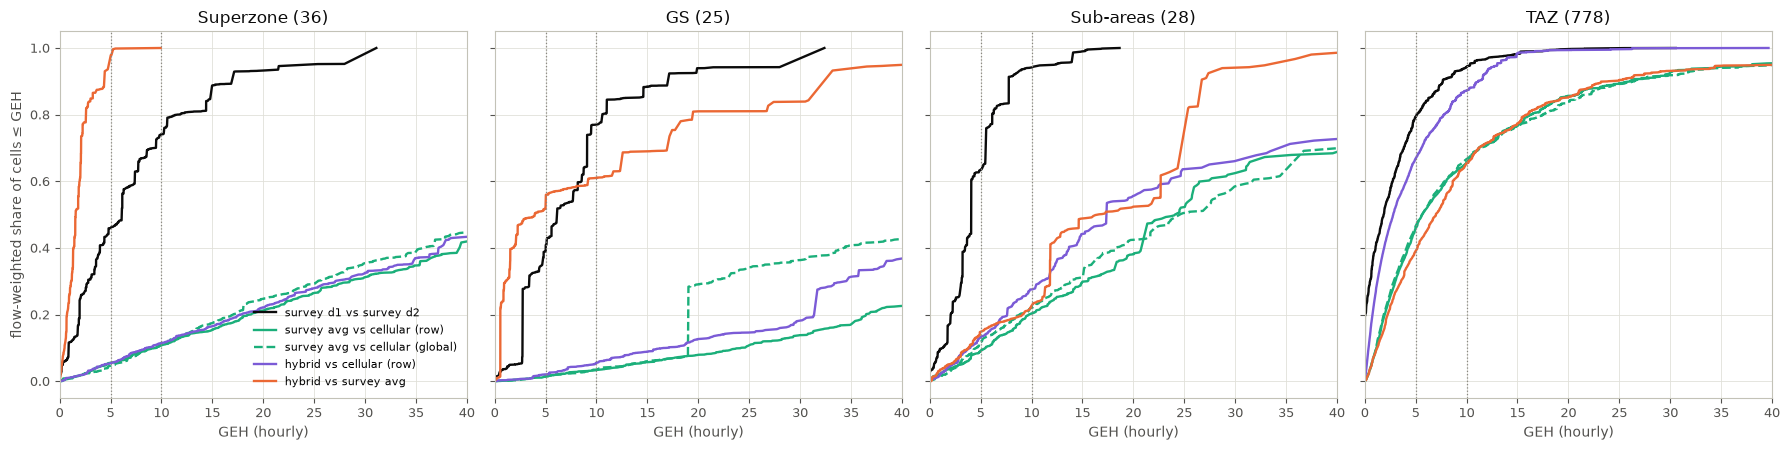

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.6), facecolor='white', sharey=True)
for ax, lvl in zip(axes, ['SZ', 'GS', 'AREA', 'TAZ']):
    for (a, b, sc), color, ls in [(('survey d1', 'survey d2', 'none'), INK, '-'), (('survey avg', 'cellular', 'row'), AQUA, '-'),
                                  (('survey avg', 'cellular', 'global'), AQUA, '--'), (('hybrid', 'cellular', 'row'), PURPLE, '-'),
                                  (('hybrid', 'survey avg', 'none'), ORANGE, '-')]:
        A, B = GEH_CELLS[(lvl, a, b, sc)]
        G = geh(A, B); w = (A + B) / 6.0; ok = ~np.isnan(G)
        o = np.argsort(G[ok]); cw = np.cumsum(w[ok][o]) / w[ok].sum()
        ax.plot(G[ok][o], cw, color=color, linestyle=ls, linewidth=1.7, label=f'{a} vs {b}' + (f' ({sc})' if sc != 'none' else ''))
    ax.axvline(5, color=MUTED, linewidth=0.9, linestyle=':'); ax.axvline(10, color=MUTED, linewidth=0.9, linestyle=':')
    ax.set_xlim(0, 40)
    style_ax(ax, f'{ {"SZ": "Superzone (36)", "GS": "GS (25)", "AREA": "Sub-areas (28)", "TAZ": "TAZ (778)"}[lvl] }', 'GEH (hourly)', 'flow-weighted share of cells ≤ GEH' if lvl == 'SZ' else None)
axes[0].legend(frameon=False, fontsize=8, loc='lower right')
plt.tight_layout()
save_show(fig, 'cosine_geh_cdf.png')

## G3. Corridor GEH — screenline-style classes and the 28 sub-areas

For the LRT question the cells that matter are the corridor ones. Flows are classed by trip ends relative to the 119 corridor TAZs (both ends in the corridor / corridor → outside / outside → corridor / neither), and the 28 aggregated sub-areas are compared cell by cell with the corridor superzones' outbound totals.

In [18]:
cls = np.where(corridor[:, None] & corridor[None, :], 'corridor→corridor',
      np.where(corridor[:, None] & ~corridor[None, :], 'corridor→outside',
      np.where(~corridor[:, None] & corridor[None, :], 'outside→corridor', 'outside→outside')))
CLASSES = ['corridor→corridor', 'corridor→outside', 'outside→corridor', 'outside→outside']
cc_rows = []
for a, b, sc in [('survey d1', 'survey d2', 'none'), ('survey avg', 'cellular', 'global'), ('survey avg', 'cellular', 'row'),
                 ('hybrid', 'cellular', 'global'), ('hybrid', 'cellular', 'row'), ('hybrid', 'survey avg', 'none')]:
    A, B = GEH_CELLS[('TAZ', a, b, sc)]
    for k in CLASSES:
        m = cls == k
        va, vb = A[m].sum(), B[m].sum()
        cc_rows.append({'pair': f'{a} vs {b}', 'scaling': sc, 'class': k, 'A trips': va, 'B trips': vb, 'ratio B/A': vb / va,
                        'GEH (class total)': float(geh(va, vb)), 'cells GEH<5 (flow-wtd)': geh_summary(A[m], B[m])['GEH<5 (flow-wtd)']})
cc_tbl = pd.DataFrame(cc_rows)
cc_tbl.to_csv(f'{OUT}/geh_corridor_classes.csv', index=False, float_format='%.4f')
cc_tbl.set_index(['pair', 'scaling', 'class']).round(3)

A trips      B trips  \
pair                   scaling class                                         
survey d1 vs survey d2 none    corridor→corridor   110791.157   110491.850   
                               corridor→outside     67922.923    71006.392   
                               outside→corridor    121368.547   120952.555   
                               outside→outside    1777219.369  1756564.132   
survey avg vs cellular global  corridor→corridor   110641.504    94125.505   
                               corridor→outside     69464.657   151473.936   
                               outside→corridor    121160.551   265636.400   
                               outside→outside    1766891.750  1556922.621   
                       row     corridor→corridor   110641.504    71057.728   
                               corridor→outside     69464.657   109048.433   
                               outside→corridor    121160.551   251327.152   
                               outside→outside    1766891.750  1636725.149   
hybrid vs cellular     global  corridor→corridor    94610.204    94125.496   
                               corridor→outside     91680.053   151473.921   
                               outside→corridor    138008.390   265636.374   
                               outside→outside    1743859.614  1556922.470   
                       row     corridor→corridor    94610.204    70668.604   
                               corridor→outside     91680.053   115621.653   
                               outside→corridor    138008.390   252688.365   
                               outside→outside    1743859.614  1629179.639   
hybrid vs survey avg   none    corridor→corridor    94610.204   110641.504   
                               corridor→outside     91680.053    69464.657   
                               outside→corridor    138008.390   121160.551   
                               outside→outside    1743859.614  1766891.750   

                                                  ratio B/A  \
pair                   scaling class                          
survey d1 vs survey d2 none    corridor→corridor      0.997   
                               corridor→outside       1.045   
                               outside→corridor       0.997   
                               outside→outside        0.988   
survey avg vs cellular global  corridor→corridor      0.851   
                               corridor→outside       2.181   
                               outside→corridor       2.192   
                               outside→outside        0.881   
                       row     corridor→corridor      0.642   
                               corridor→outside       1.570   
                               outside→corridor       2.074   
                               outside→outside        0.926   
hybrid vs cellular     global  corridor→corridor      0.995   
                               corridor→outside       1.652   
                               outside→corridor       1.925   
                               outside→outside        0.893   
                       row     corridor→corridor      0.747   
                               corridor→outside       1.261   
                               outside→corridor       1.831   
                               outside→outside        0.934   
hybrid vs survey avg   none    corridor→corridor      1.169   
                               corridor→outside       0.758   
                               outside→corridor       0.878   
                               outside→outside        1.013   

                                                  GEH (class total)  \
pair                   scaling class                                  
survey d1 vs survey d2 none    corridor→corridor              0.520   
                               corridor→outside               6.755   
                               outside→corridor               0.690   
                               

In [19]:
# 28 aggregated sub-areas: cell-level GEH, and per-area origin totals
area_rows = []
for a, b, sc in [('survey d1', 'survey d2', 'none'), ('survey avg', 'cellular', 'row'), ('hybrid', 'cellular', 'row'), ('hybrid', 'survey avg', 'none')]:
    A, B = GEH_CELLS[('AREA', a, b, sc)]
    G = geh(A, B)
    area_rows.append(pd.DataFrame({'pair': f'{a} vs {b}', 'origin area': np.repeat(AREA, len(AREA)), 'dest area': np.tile(AREA, len(AREA)),
                                   'A hourly': (A / 3).ravel(), 'B hourly': (B / 3).ravel(), 'GEH': G.ravel()}))
area_cells = pd.concat(area_rows)
area_cells['origin name'] = area_cells['origin area'].map(area_names); area_cells['dest name'] = area_cells['dest area'].map(area_names)
area_cells.to_csv(f'{OUT}/geh_area_cells.csv', index=False, float_format='%.3f')

worst = (area_cells[(area_cells['pair'] == 'hybrid vs cellular') & (area_cells['A hourly'] + area_cells['B hourly'] > 100)]
         .sort_values('GEH', ascending=False).head(12))
print("largest hybrid-vs-cellular (row-matched) disagreements among sub-area cells with > 100 trips/h:")
print(worst[['origin name', 'dest name', 'A hourly', 'B hourly', 'GEH']].round(1).to_string(index=False))

A, B = GEH_CELLS[('AREA', 'hybrid', 'cellular', 'row')]
big = (A + B) / 6 > 100
print(f"\nsub-area cells with > 100 trips/h: {big.sum()} of {len(AREA)**2}; hybrid vs cellular (row) GEH<5 among them: {(geh(A, B)[big] < 5).mean():.0%}; "
      f"survey d1 vs d2: {(geh(*GEH_CELLS[('AREA', 'survey d1', 'survey d2', 'none')])[big] < 5).mean():.0%}")

largest hybrid-vs-cellular (row-matched) disagreements among sub-area cells with > 100 trips/h:
          origin name             dest name  A hourly  B hourly  GEH
Kiryat Motzkin-Bialik Kiryat Motzkin-Bialik   18171.9    9142.9 77.3
     Kiryat Ata South      Kiryat Ata South    4993.9    1694.5 57.1
          TiratCarmel           TiratCarmel    3937.4    1321.3 51.0
           Kiryat Yam            Kiryat Yam    6365.0    3070.2 48.0
Kiryat Motzkin-Bialik          Kiryat Nahum     308.9    1643.6 42.7
Kiryat Motzkin-Bialik            Lower City     336.5    1471.1 37.7
         Nesher Lower          Nesher Lower    2801.5    1215.4 35.4
       Kiryat Eliezer        Kiryat Eliezer     877.3     127.7 33.4
         Alon Hagalil          Alon Hagalil     995.0     189.8 33.1
         Hadar Carmel          Hadar Carmel    1393.1     426.1 32.1
Kiryat Motzkin-Bialik             Bat Galim     297.5    1118.0 30.8
          TiratCarmel            Lower City      86.2     666.8 29.9

sub-ar

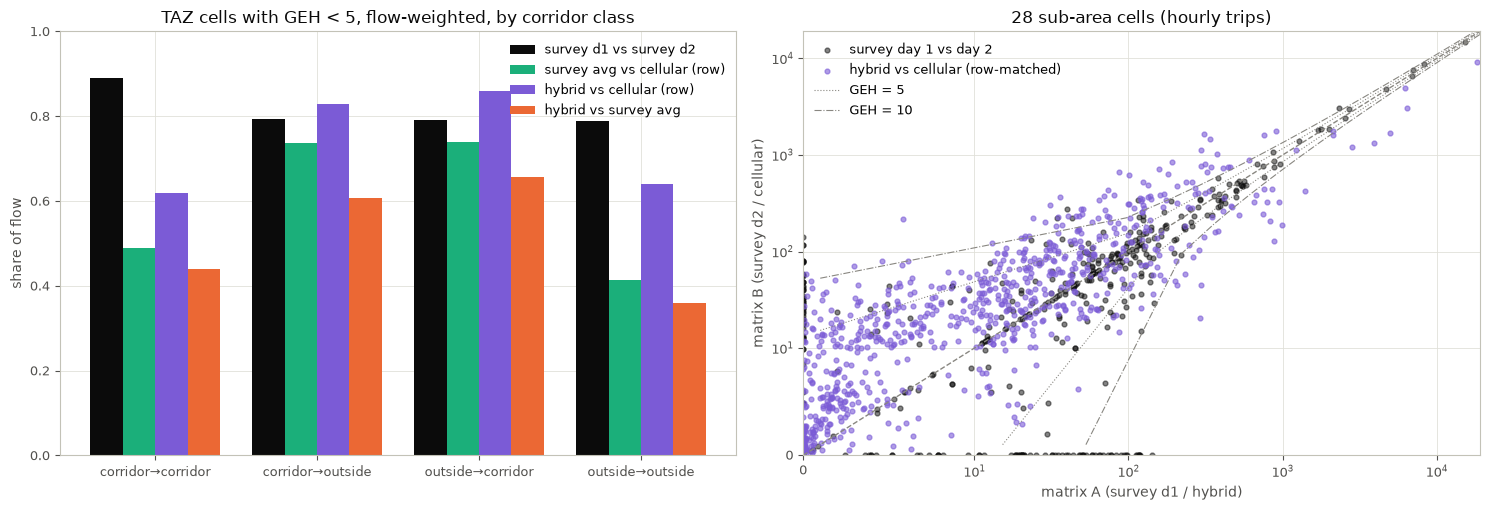

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), facecolor='white')
ax = axes[0]
sub = cc_tbl[cc_tbl['scaling'] != 'global']
pairs_c = ['survey d1 vs survey d2', 'survey avg vs cellular', 'hybrid vs cellular', 'hybrid vs survey avg']
colors_c = [INK, AQUA, PURPLE, ORANGE]
x = np.arange(len(CLASSES)); wdt = 0.2
for i, (p, col) in enumerate(zip(pairs_c, colors_c)):
    s = sub[sub['pair'] == p].set_index('class').loc[CLASSES]
    ax.bar(x + (i - 1.5) * wdt, s['cells GEH<5 (flow-wtd)'], width=wdt, color=col, label=p + (' (row)' if 'cellular' in p else ''))
ax.set_xticks(x); ax.set_xticklabels(CLASSES, color=INK2)
ax.set_ylim(0, 1)
style_ax(ax, 'TAZ cells with GEH < 5, flow-weighted, by corridor class', None, 'share of flow')
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
A, B = GEH_CELLS[('AREA', 'hybrid', 'cellular', 'row')]
A1, B1 = GEH_CELLS[('AREA', 'survey d1', 'survey d2', 'none')]
ax.scatter((A1 / 3).ravel(), (B1 / 3).ravel(), s=12, alpha=0.5, color=INK, label='survey day 1 vs day 2')
ax.scatter((A / 3).ravel(), (B / 3).ravel(), s=12, alpha=0.6, color=PURPLE, label='hybrid vs cellular (row-matched)')
lim = max((A / 3).max(), (B1 / 3).max()) * 1.05
ax.plot([0, lim], [0, lim], color=MUTED, linewidth=1, linestyle='--')
for gval, ls in [(5, ':'), (10, '-.')]:
    xs = np.linspace(1, lim, 200)
    # GEH = g  <=>  (m-c)^2 = g^2 (m+c)/2  =>  c = m + g^2/4 + sqrt(g^2 m + g^4/16)  (upper branch; lower branch by symmetry)
    cs = xs + gval**2 / 4 + np.sqrt(gval**2 * xs + gval**4 / 16)
    ax.plot(xs, cs, color=MUTED, linewidth=0.8, linestyle=ls, label=f'GEH = {gval}')
    ax.plot(cs, xs, color=MUTED, linewidth=0.8, linestyle=ls)
ax.set_xscale('symlog', linthresh=10); ax.set_yscale('symlog', linthresh=10)
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
style_ax(ax, '28 sub-area cells (hourly trips)', 'matrix A (survey d1 / hybrid)', 'matrix B (survey d2 / cellular)')
ax.legend(frameon=False, fontsize=9, loc='upper left')
plt.tight_layout()
save_show(fig, 'cosine_geh_corridor.png')

## Summary table

In [21]:
def pick(tbl, **kw):
    q = tbl
    for k, v in kw.items(): q = q[q[k] == v]
    return q.iloc[0]

summary = []
for lvl in ['SZ', 'GS', 'AREA', 'TAZ']:
    for pair, sc in [('survey d1 vs survey d2', 'none'), ('survey avg vs cellular', 'row'), ('hybrid vs cellular', 'row'), ('hybrid vs survey avg', 'none')]:
        c_ = pick(cos_tbl, level=lvl, pair=pair); g_ = pick(geh_tbl, level=lvl, pair=pair, scaling=sc)
        r_ = pick(row_summary, level=lvl, pair=pair.replace('survey avg vs cellular', 'survey vs cellular').replace('hybrid vs survey avg', 'hybrid vs survey').replace('survey d1 vs survey d2', 'd1 vs d2'))
        summary.append({'level': lvl, 'pair': pair, 'cosine raw': c_['raw'], 'cosine off-diag': c_['off-diagonal'], 'cosine row-norm': c_['row-normalized'],
                        'per-origin cosine (flow-wtd)': r_['flow-weighted mean'], 'GEH scaling': sc,
                        'GEH<5 (flow-wtd)': g_['GEH<5 (flow-wtd)'], 'GEH<10 (flow-wtd)': g_['GEH<10 (flow-wtd)'], 'GEH<5 off-diag (flow-wtd)': g_['GEH<5 off-diag (flow-wtd)']})
summary = pd.DataFrame(summary)
summary.to_csv(f'{OUT}/cosine_geh_summary.csv', index=False, float_format='%.4f')
print(f"outputs written to {OUT}/ and Output/figures/cosine_geh_*.png")
summary.set_index(['level', 'pair']).round(3)

outputs written to Output/ths2017/tests/ and Output/figures/cosine_geh_*.png


cosine raw  cosine off-diag  cosine row-norm  \
level pair                                                                   
SZ    survey d1 vs survey d2       0.996            0.974            0.998   
      survey avg vs cellular       0.915            0.851            0.870   
      hybrid vs cellular           0.917            0.859            0.874   
      hybrid vs survey avg         1.000            0.999            1.000   
GS    survey d1 vs survey d2       0.999            0.983            0.986   
      survey avg vs cellular       0.953            0.914            0.852   
      hybrid vs cellular           0.963            0.866            0.891   
      hybrid vs survey avg         0.994            0.903            0.968   
AREA  survey d1 vs survey d2       0.997            0.978            0.885   
      survey avg vs cellular       0.897            0.683            0.681   
      hybrid vs cellular           0.902            0.804            0.805   
      hybrid vs survey avg         0.960            0.855            0.842   
TAZ   survey d1 vs survey d2       0.972            0.940            0.675   
      survey avg vs cellular       0.442            0.417            0.437   
      hybrid vs cellular           0.734            0.737            0.825   
      hybrid vs survey avg         0.432            0.538            0.484   

                              per-origin cosine (flow-wtd) GEH scaling  \
level pair                                                               
SZ    survey d1 vs survey d2                         0.999        none   
      survey avg vs cellular                         0.889         row   
      hybrid vs cellular                             0.893         row   
      hybrid vs survey avg                           1.000        none   
GS    survey d1 vs survey d2                         0.999        none   
      survey avg vs cellular                         0.894         row   
      hybrid vs cellular                             0.920         row   
      hybrid vs survey avg                           0.980        none   
AREA  survey d1 vs survey d2                         0.980        none   
      survey avg vs cellular                         0.807         row   
      hybrid vs cellular                             0.857         row   
      hybrid vs survey avg                           0.940        none   
TAZ   survey d1 vs survey d2                         0.934        none   
      survey avg vs cellular                         0.595         row   
      hybrid vs cellular                             0.831         row   
      hybrid vs survey avg                           0.674        none   

                              GEH<5 (flow-wtd)  GEH<10 (flow-wtd)  \
level pair                                                          
SZ    survey d1 vs survey d2             0.459              0.741   
      survey avg vs cellular             0.055              0.108   
      hybrid vs cellular                 0.054              0.115   
      hybrid vs survey avg               0.936              1.000   
GS    survey d1 vs survey d2             0.390              0.769   
      survey avg vs cellular             0.013              0.034   
      hybrid vs cellular                 0.021              0.055   
      hybrid vs survey avg               0.517              0.610   
AREA  survey d1 vs survey d2             0.632              0.941   
      survey avg vs cellular             0.091              0.204   
      hybrid vs cellular                 0.132              0.275   
      hybrid vs survey avg               0.149              0.226   
TAZ   survey d1 vs survey d2             0.794              0.943   
      survey avg vs cellular             0.459              0.657   
      hybrid vs cellular                 0.669              0.872   
      hybrid vs survey avg               0.391              0.654   

                              GEH<5 off-diag (flo

## Notes

- **Survey source.** Only `Input/trips_ths_2017.xlsx` (survey days 1 / 2) is read; the activities file (days 10 / 20) is not touched, and the rebuilt day-average is asserted to equal the saved `matrix_avg_ALL_taz.csv` of the trips-file pipeline.
- **Cellular volumes.** The pipeline consumes cellular as probabilities, where the replication of a 1250-zone-pair value over every child-TAZ pair is harmless. For volume tests it is not (the study-area replicated total is 6.4 × the native one), so all GEH runs use the allocated, total-preserving TAZ matrix; the replicated probabilities are shown as a sensitivity in C1 only. Below the cellular zone, both the survey and the cellular TAZ pattern are cellular allocation shares, so the TAZ-level rows compare pattern down to the 1250-zone level plus a shared within-zone split — TAZ-level agreement is flattered by construction, SZ / GS / sub-area levels are the fair comparison.
- **GEH on absolute volumes** mostly measures the scale gap between household expansion and the cellular product's trip definition (task B1 of `CORRIDOR_DEMAND_TASKS.md`); the scale-matched runs are the pattern tests. GEH is a link-count criterion; applied to OD cells the 85 % / GEH < 5 convention is a yardstick, not a standard.
- **Row-matched vs global.** Row-matched removes origin-total disagreement, so `hybrid vs cellular (row)` is a pure measure of the correction factors' effect; `survey vs cellular (global)` additionally carries the difference in where trips start.